In [2]:
from pathlib import Path
%pip install matplotlib pandas rdkit
import pandas as pd
# Install matplotlib if it is not available in the current environment
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    !{sys.executable} -m pip install matplotlib
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    !{sys.executable} -m pip install matplotlib
    import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
import sys
from rdkit.Chem import (
    Draw,
    Descriptors,
    MACCSkeys,
    rdFingerprintGenerator,
)

Note: you may need to restart the kernel to use updated packages.


In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [6]:
from pathlib import Path
import pandas as pd
from rdkit import Chem

pd.read_csv("data/Similarity_Scaffold_Compounds.tsv", sep="\t").to_csv("data/Similarity_Scaffold_Compounds.csv", index=False)



csv_path = Path.cwd().parent / "data" / "Similarity_Scaffold_Compounds.csv"

if not csv_path.exists():
    csv_path = DATA / "Similarity_Scaffold_Compounds.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Data file not found: {csv_path}")

df = pd.read_csv(csv_path)
mols = []

smiles_column = "smiles" if "smiles" in df.columns else "alignment"

# Provide the expected column name for later cells
df["smiles"] = df[smiles_column]

for i, smiles in enumerate(df["smiles"].dropna().astype(str), start=1):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol.SetProp("_Name", f"Compound_{i}")
        mols.append(mol)

print(f"Set with {len(mols)} molecules loaded.")
# NBVAL_CHECK_OUTPUT

Set with 1648 molecules loaded.


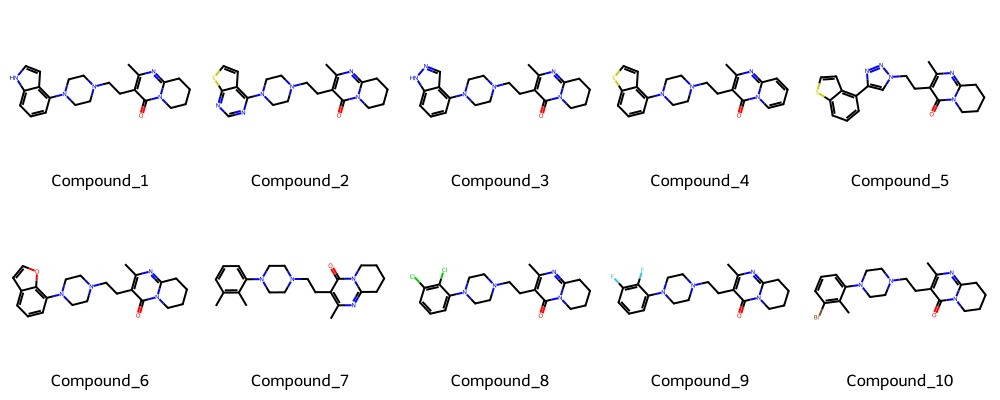

In [7]:
# Show only first 10 molecules -- use slicing
num_mols = 10
legends = [mol.GetProp("_Name") for mol in mols]
Draw.MolsToGridImage(mols[:num_mols], legends=legends[:num_mols], molsPerRow=5)

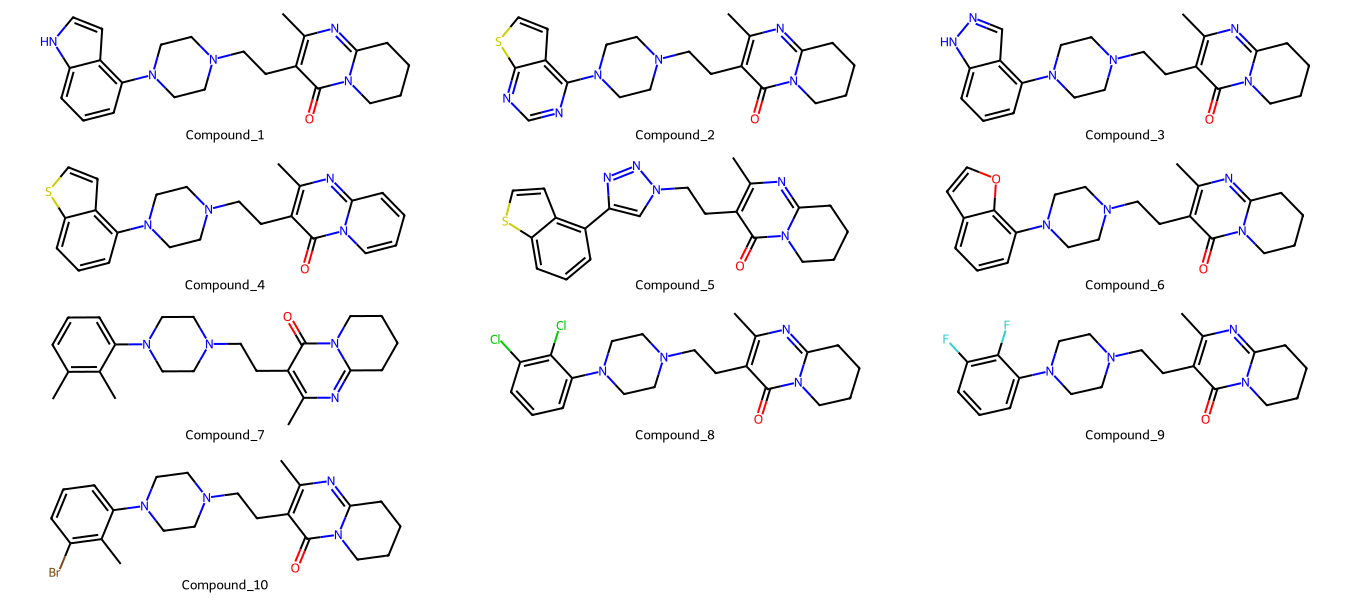

In [8]:
# Use the molecules and legends already created earlier in the notebook
img = Draw.MolsToGridImage(
    mols[:10],
    molsPerRow=3,
    subImgSize=(450, 150),
    legends=legends[:10],
)
img


In [10]:
# Create the dataframe expected by the following cells
molecules = df.copy()

# Convert SMILES to RDKit molecules and remove invalid entries
molecules["mol"] = molecules["smiles"].map(Chem.MolFromSmiles)
molecules = molecules[molecules["mol"].notna()].reset_index(drop=True)

# Generate MACCS fingerprints
molecules["maccs"] = molecules["mol"].map(MACCSkeys.GenMACCSKeys)

In [11]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator()

molecules["morgan"] = molecules["smiles"].apply(lambda smiles: morgan_generator.GetFingerprint(Chem.MolFromSmiles(smiles)))

In [12]:
# Define molecule query and list
molecule_query = molecules["maccs"][0]
molecule_list = molecules["maccs"].to_list()
# Calculate similarty values between query and list elements
molecules["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_maccs"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

In [13]:
preview = molecules.sort_values(["tanimoto_maccs"], ascending=False).reset_index()
preview[["smiles", "tanimoto_maccs", "dice_maccs"]]
# NBVAL_CHECK_OUTPUT

,smiles,tanimoto_maccs,dice_maccs
0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,1.000000,1.000000
1,CC1=C(C(=O)N2C=CC=CC2=N1)CCN3CCN(CC3)C4=CC=CC5...,1.000000,1.000000
2,CC1=C(C(=O)N2C=CC=CC2=N1)CCN3CCN(CC3)C4=C5C=CN...,1.000000,1.000000
3,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=C5NC=...,1.000000,1.000000
4,CC1=C(C(=O)N2C=CC=CC2=N1)CCN3CCN(CC3)C4=CC=C5N...,1.000000,1.000000
...,...,...,...
1643,COC1=CC=CC(=C1)N2CCC(CC2)NCC3=C(C4=C(C=C3Br)OC...,0.583333,0.736842
1644,O=C(OC1=C(C2=C(C=C1)OCCO2)Cl)N3CCN(CC3)C4=CC=C...,0.573333,0.728814
1645,COC1=CC=CC=C1N2CCC(CC2)NCC3=C(C4=C(C=C3Br)OCCO...,0.561644,0.719298
1646,O=C(NCC1=CC2=C(CCCC2)N=C1O)NNC(=O)C3=CC=CC4=C3...,0.554054,0.713043


In [14]:
def draw_ranked_molecules(molecules, sort_by_column):
    molecules_sorted = (
        molecules.sort_values(sort_by_column, ascending=False)
        .reset_index(drop=True)
    )
    mols = [Chem.MolFromSmiles(smiles) for smiles in molecules_sorted["smiles"]]
    legends = [
        f"#{index + 1}, similarity={row[sort_by_column]:.2f}"
        for index, row in molecules_sorted.iterrows()
    ]

    return Draw.MolsToGridImage(
        mols,
        legends=legends,
        molsPerRow=3,
        subImgSize=(450, 150),
    )

/Users/bartrabelink/miniforge3/lib/python3.14/site-packages/rdkit/Chem/Draw/IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


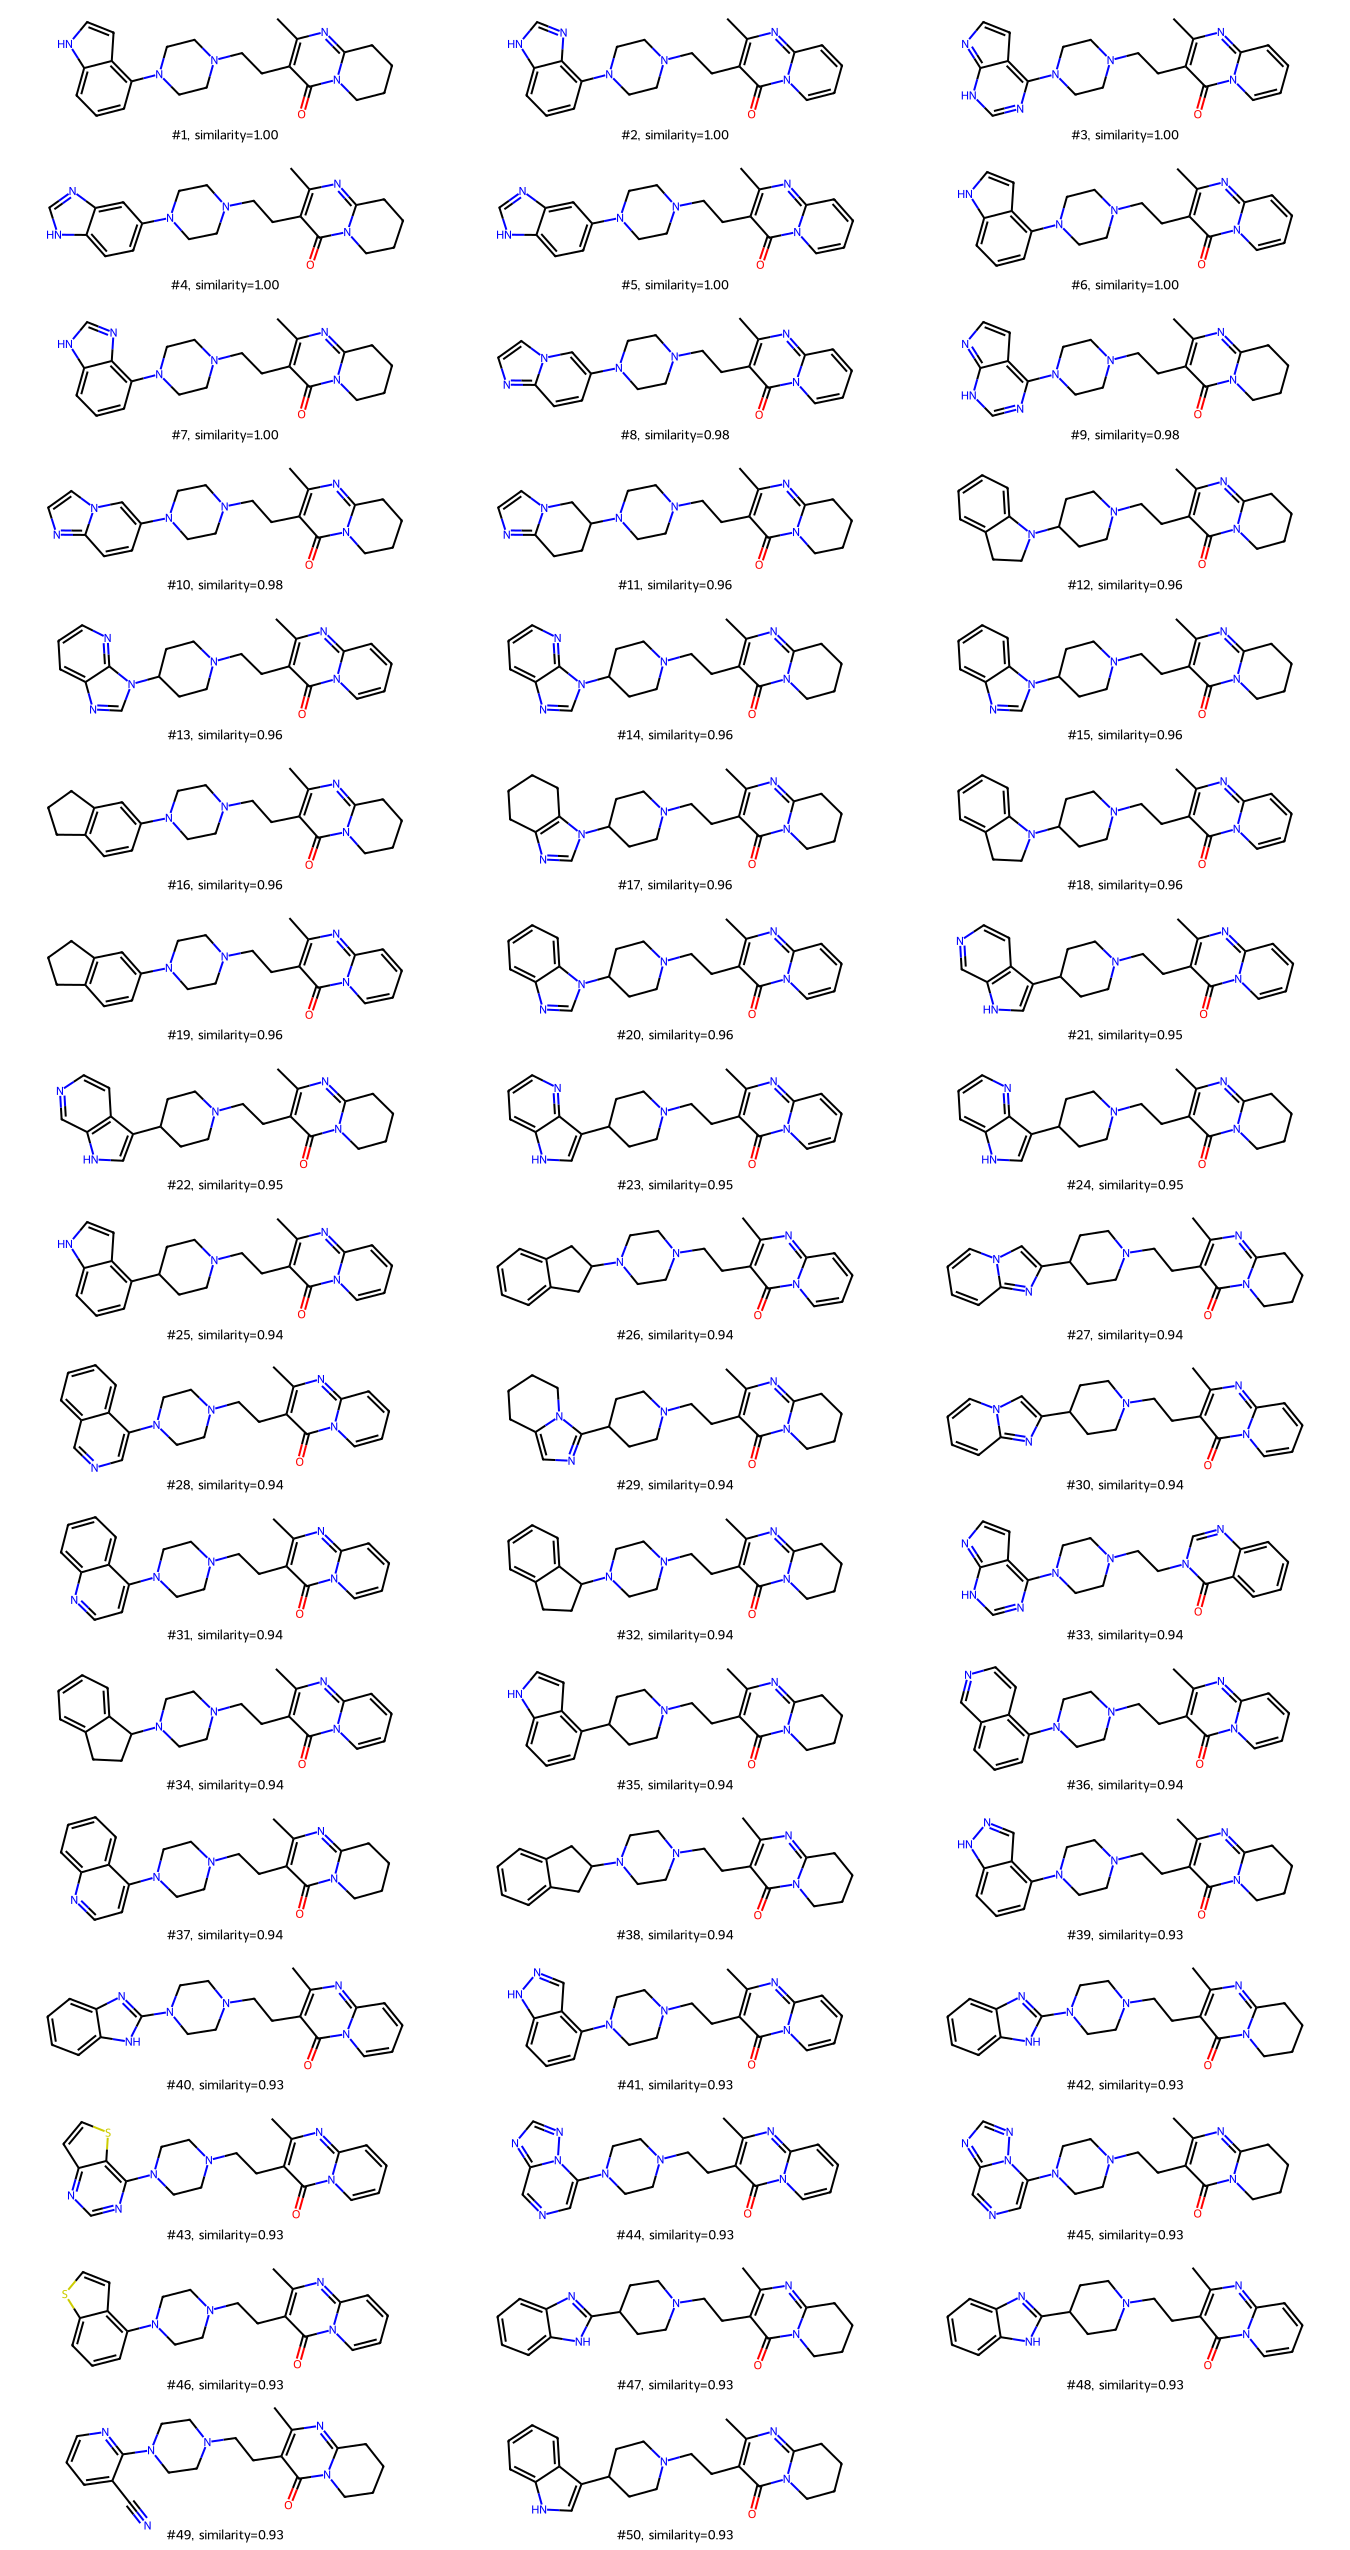

In [15]:
draw_ranked_molecules(molecules, "tanimoto_maccs")

In [16]:
# Define molecule query and list
molecule_query = molecules["morgan"][0]
molecule_list = molecules["morgan"].to_list()
# Calculate similarty values between query and list elements
molecules["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_morgan"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

In [17]:
preview = molecules.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
preview[["smiles", "tanimoto_morgan", "dice_morgan", "tanimoto_maccs", "dice_maccs"]]
# NBVAL_CHECK_OUTPUT

,smiles,tanimoto_morgan,dice_morgan,tanimoto_maccs,dice_maccs
0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,1.000000,1.000000,1.000000,1.000000
1,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,0.705263,0.827160,0.931034,0.964286
2,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC(CC3)C4=CC=CC5=C...,0.663265,0.797546,0.944444,0.971429
3,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,0.653061,0.790123,0.870968,0.931034
4,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,0.646465,0.785276,1.000000,1.000000
...,...,...,...,...,...
1643,O=C(C1CCCCC1F)N2CC[C@H](C2)N3CCN(CC3)C4=NC=NC5...,0.068027,0.127389,0.709677,0.830189
1644,O=C([C@@H]1CCCC[C@H]1O)N2CC[C@H](C2)N3CCN(CC3)...,0.067568,0.126582,0.712121,0.831858
1645,O=C(C1CCCCC1O)N2CC[C@@H](C2)N3CCN(CC3)C4=NC=NN...,0.067568,0.126582,0.712121,0.831858
1646,O=C(NCCC1CCN(CC1)C2=NC=NC3=C2SC=N3)C4CCCCC45CC...,0.067568,0.126582,0.676923,0.807339


/Users/bartrabelink/miniforge3/lib/python3.14/site-packages/rdkit/Chem/Draw/IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


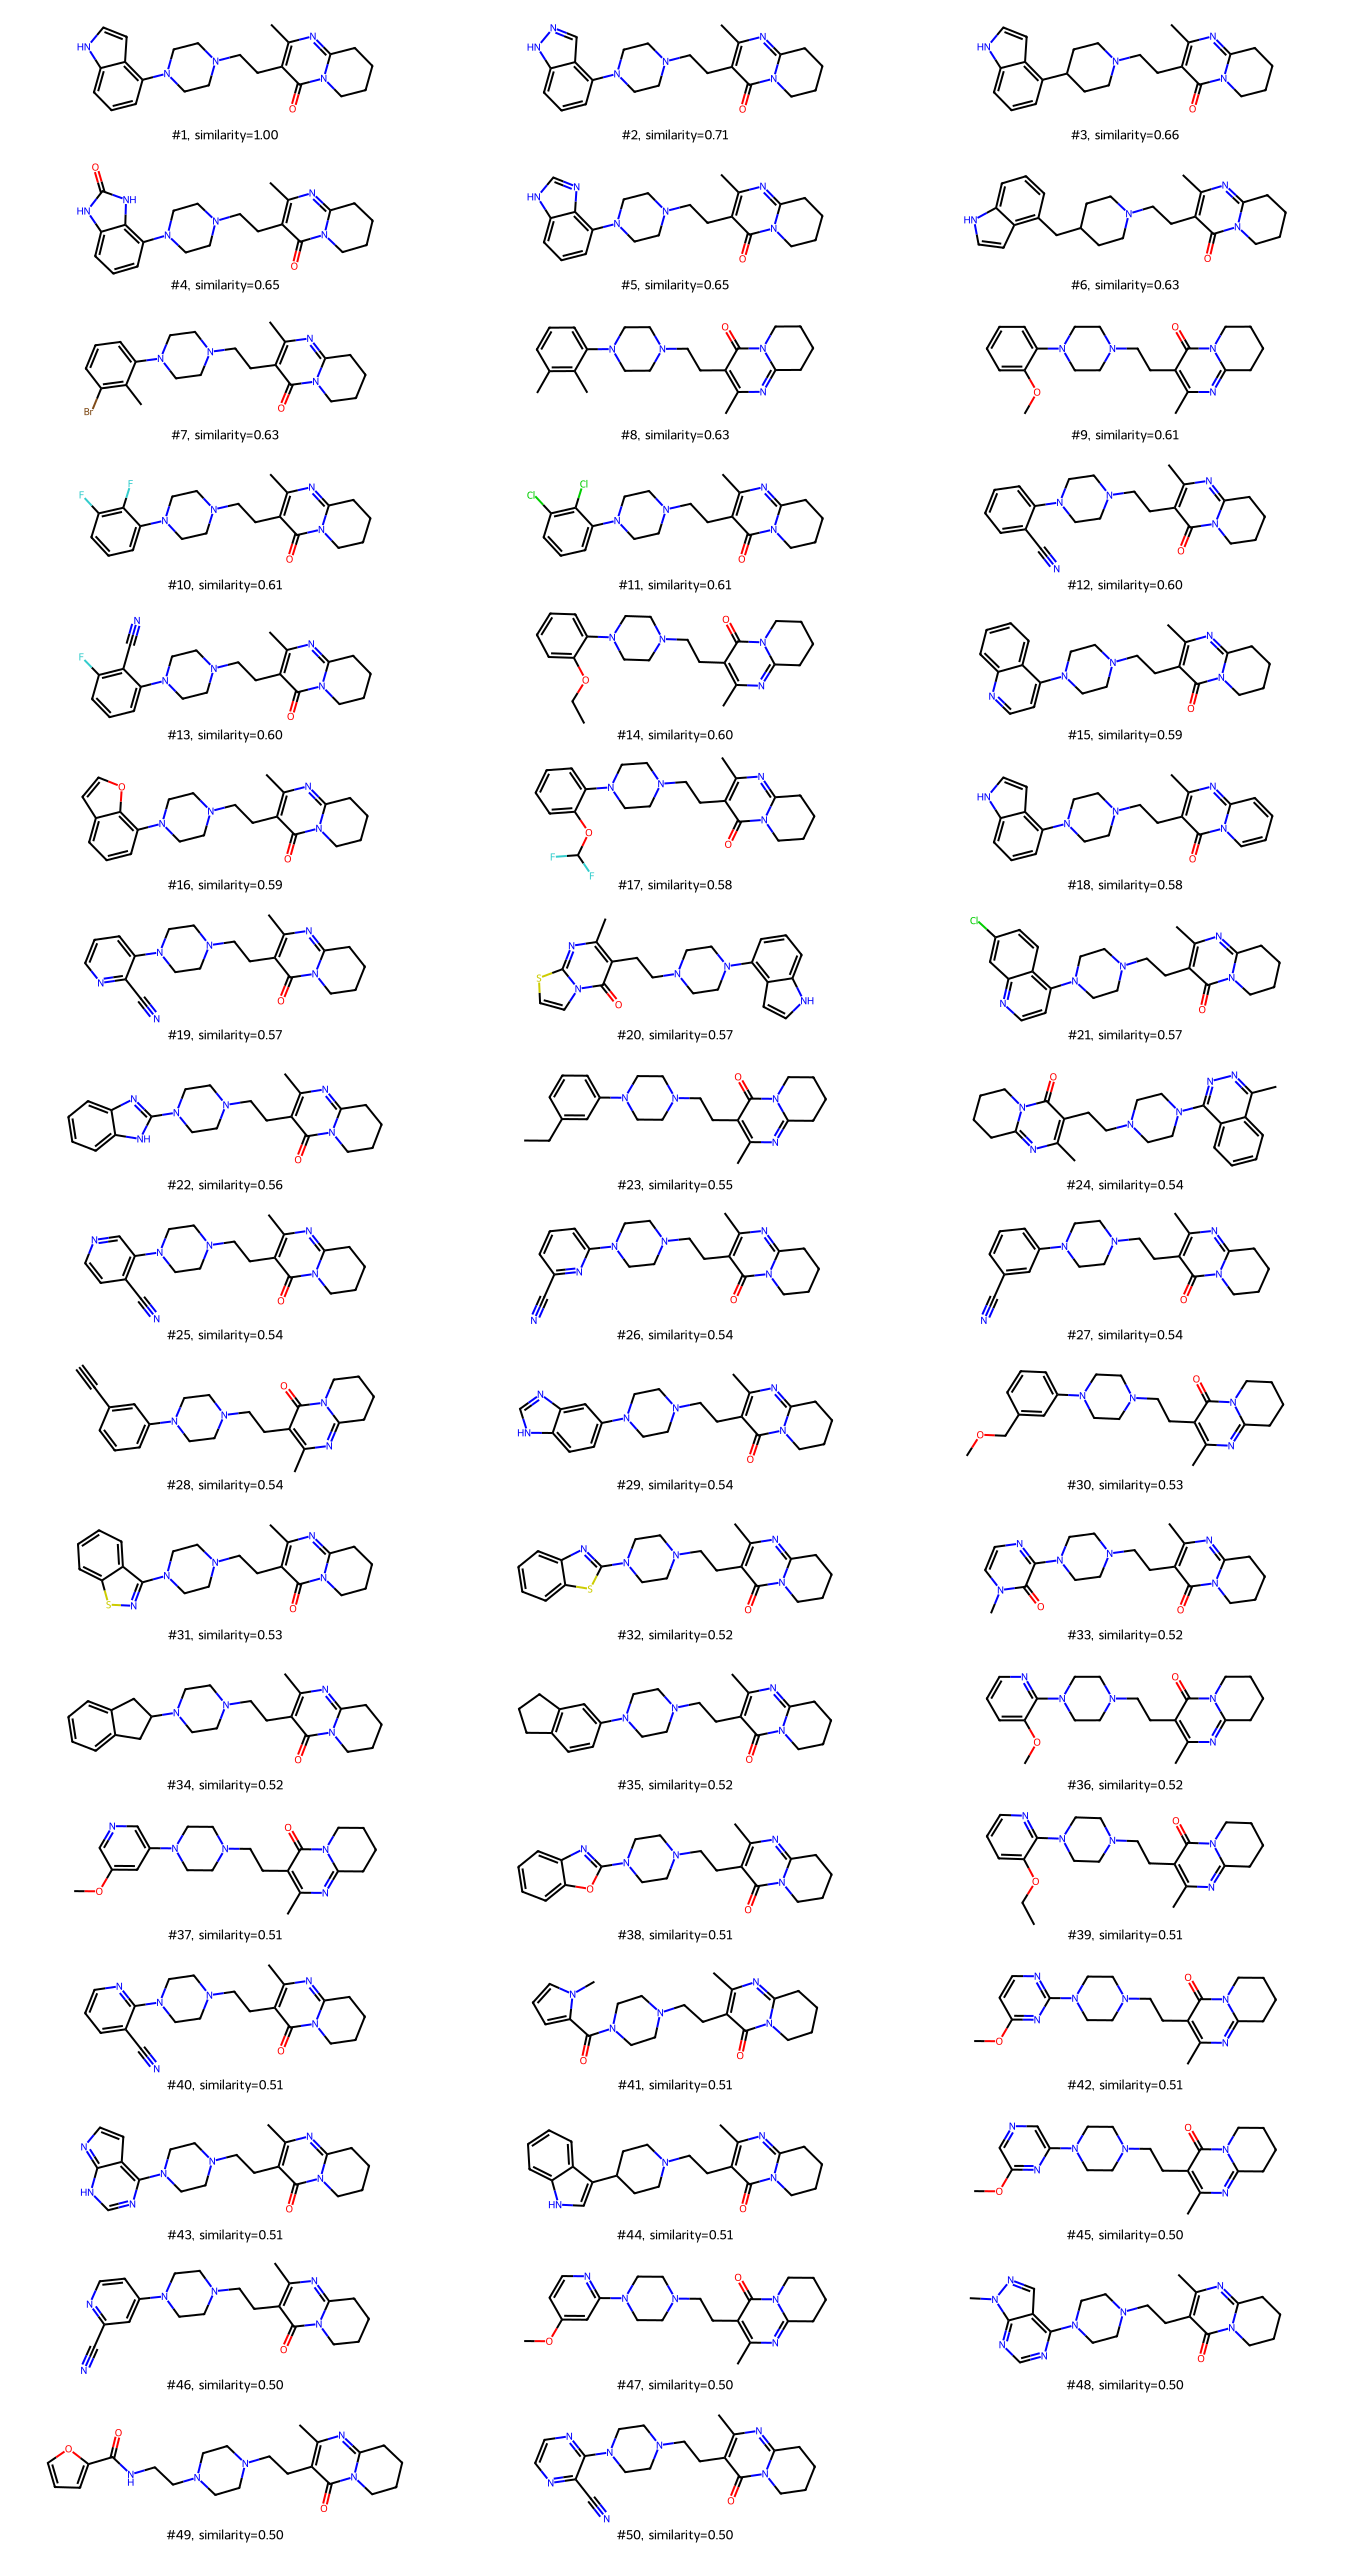

In [18]:
draw_ranked_molecules(molecules, "tanimoto_morgan")

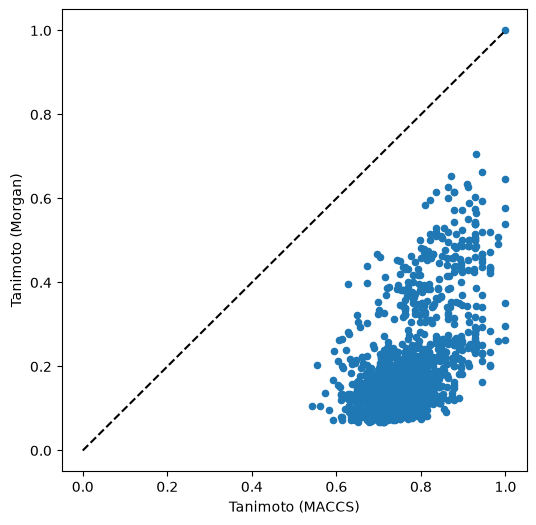

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
molecules.plot("tanimoto_maccs", "tanimoto_morgan", kind="scatter", ax=ax)
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("Tanimoto (MACCS)")
ax.set_ylabel("Tanimoto (Morgan)")
fig;

In [23]:
molecule_dataset = pd.read_csv(DATA / "Similarity_Scaffold_Compounds.csv")
molecule_dataset[["smiles", "hit_id"]] = molecule_dataset["alignment"].str.split(" ", n=1, expand=True)
print(f"Number of molecules in dataset: {len(molecule_dataset)}")
molecule_dataset.head(5)


Number of molecules in dataset: 1648


,alignment,dist,ecfp4,daylight,maj,min,hyb,sub,smiles,hit_id
0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,1,0.701493,0.733906,1,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__12304850__16949512
1,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=NC=NC5=C...,2,0.691176,0.697761,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=NC=NC5=C...,s_2230__24395838__16949512
2,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,2,0.676471,0.734783,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__17793196__16949512
3,CC1=C(C(=O)N2C=CC=CC2=N1)CCN3CCN(CC3)C4=CC=CC5...,4,0.671429,0.707510,0,0,4,0,CC1=C(C(=O)N2C=CC=CC2=N1)CCN3CCN(CC3)C4=CC=CC5...,s_2230__14793138__9780156
4,CC1=C(C(=O)N2CCCCC2=N1)CCN3C=C(N=N3)C4=CC=CC5=...,5,0.652778,0.495327,3,0,1,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3C=C(N=N3)C4=CC=CC5=...,m_282512__24308046__24220098


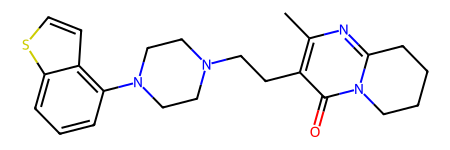

In [24]:
query = Chem.MolFromSmiles("Cc1nc2n(c(=O)c1CCN1CCN(c3cccc4sccc34)CC1)CCCC2")
query

In [25]:
maccs_fp_query = MACCSkeys.GenMACCSKeys(query)
circular_fp_query = rdFingerprintGenerator.GetCountFPs([query])[0]

In [26]:
circular_fp_list = [
    rdFingerprintGenerator.GetMorganGenerator().GetCountFingerprint(
        Chem.MolFromSmiles(smiles)
    )
    for smiles in molecule_dataset["smiles"]
]

maccs_fp_list = [
    MACCSkeys.GenMACCSKeys(
        Chem.MolFromSmiles(smiles)
    )
    for smiles in molecule_dataset["smiles"]
]

In [27]:
molecule_dataset["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(
    maccs_fp_query, maccs_fp_list
)
molecule_dataset["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(
    circular_fp_query, circular_fp_list
)

In [28]:
molecule_dataset["dice_maccs"] = DataStructs.BulkDiceSimilarity(maccs_fp_query, maccs_fp_list)
molecule_dataset["dice_morgan"] = DataStructs.BulkDiceSimilarity(
    circular_fp_query, circular_fp_list
)

In [29]:
# NBVAL_CHECK_OUTPUT
molecule_dataset[
    ["smiles", "tanimoto_maccs", "tanimoto_morgan", "dice_maccs", "dice_morgan"]
].head(5)

,smiles,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,0.929825,0.625000,0.963636,0.769231
1,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=NC=NC5=C...,0.982456,0.560000,0.991150,0.717949
2,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,0.868852,0.598361,0.929825,0.748718
3,CC1=C(C(=O)N2C=CC=CC2=N1)CCN3CCN(CC3)C4=CC=CC5...,1.000000,0.523438,1.000000,0.687179
4,CC1=C(C(=O)N2CCCCC2=N1)CCN3C=C(N=N3)C4=CC=CC5=...,0.868852,0.484615,0.929825,0.652850


In [30]:
# Show all columns
molecule_dataset.head(3)

,alignment,dist,ecfp4,daylight,maj,min,hyb,sub,smiles,hit_id,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,1,0.701493,0.733906,1,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__12304850__16949512,0.929825,0.625000,0.963636,0.769231
1,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=NC=NC5=C...,2,0.691176,0.697761,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=NC=NC5=C...,s_2230__24395838__16949512,0.982456,0.560000,0.991150,0.717949
2,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,2,0.676471,0.734783,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__17793196__16949512,0.868852,0.598361,0.929825,0.748718


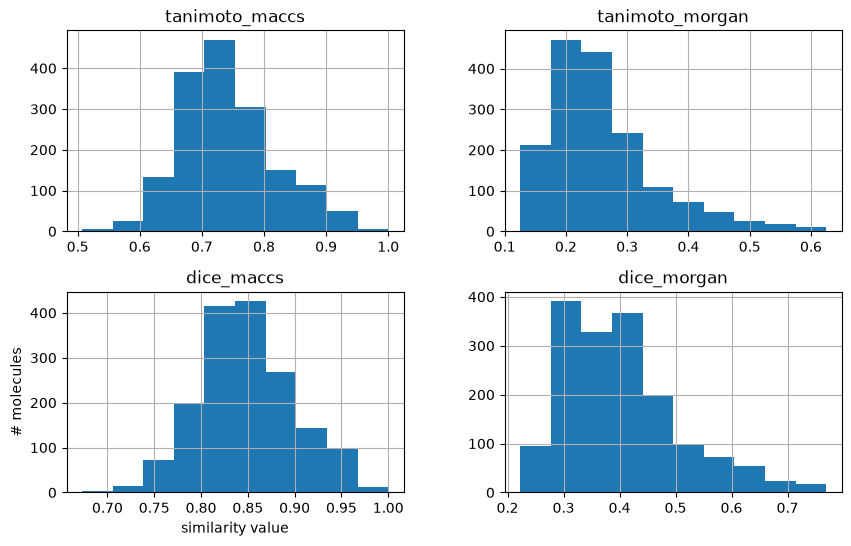

In [31]:
fig, axes = plt.subplots(figsize=(10, 6), nrows=2, ncols=2)
molecule_dataset.hist(["tanimoto_maccs"], ax=axes[0, 0])
molecule_dataset.hist(["tanimoto_morgan"], ax=axes[0, 1])
molecule_dataset.hist(["dice_maccs"], ax=axes[1, 0])
molecule_dataset.hist(["dice_morgan"], ax=axes[1, 1])
axes[1, 0].set_xlabel("similarity value")
axes[1, 0].set_ylabel("# molecules")
fig;

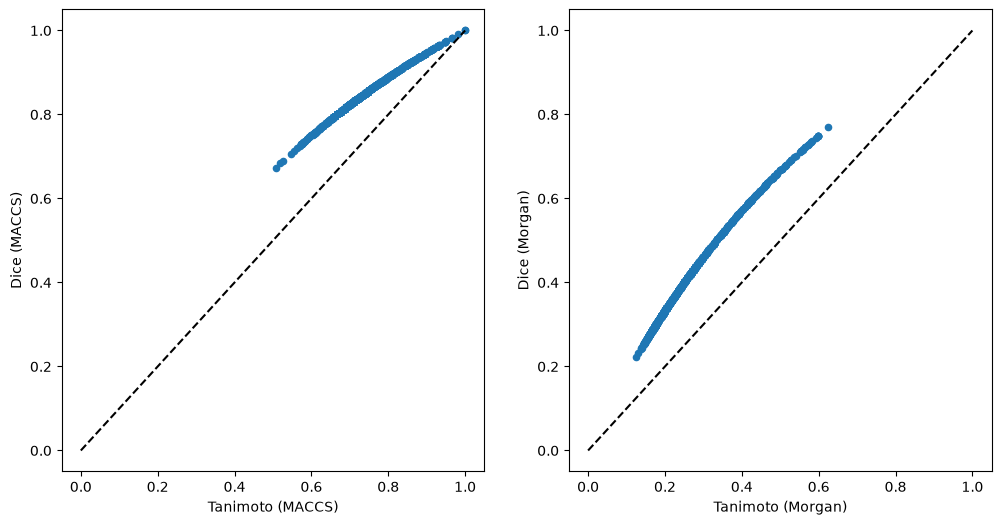

In [32]:
fig, axes = plt.subplots(figsize=(12, 6), nrows=1, ncols=2)

molecule_dataset.plot("tanimoto_maccs", "dice_maccs", kind="scatter", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("Tanimoto (MACCS)")
axes[0].set_ylabel("Dice (MACCS)")

molecule_dataset.plot("tanimoto_morgan", "dice_morgan", kind="scatter", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("Tanimoto (Morgan)")
axes[1].set_ylabel("Dice (Morgan)")

fig;

In [33]:
molecule_dataset.sort_values(["tanimoto_morgan"], ascending=False).head(3)

,alignment,dist,ecfp4,daylight,maj,min,hyb,sub,smiles,hit_id,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,1,0.701493,0.733906,1,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__12304850__16949512,0.929825,0.625000,0.963636,0.769231
2,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,2,0.676471,0.734783,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__17793196__16949512,0.868852,0.598361,0.929825,0.748718
5,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,2,0.652174,0.735931,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__28471962__16949512,0.883333,0.598361,0.938053,0.748718


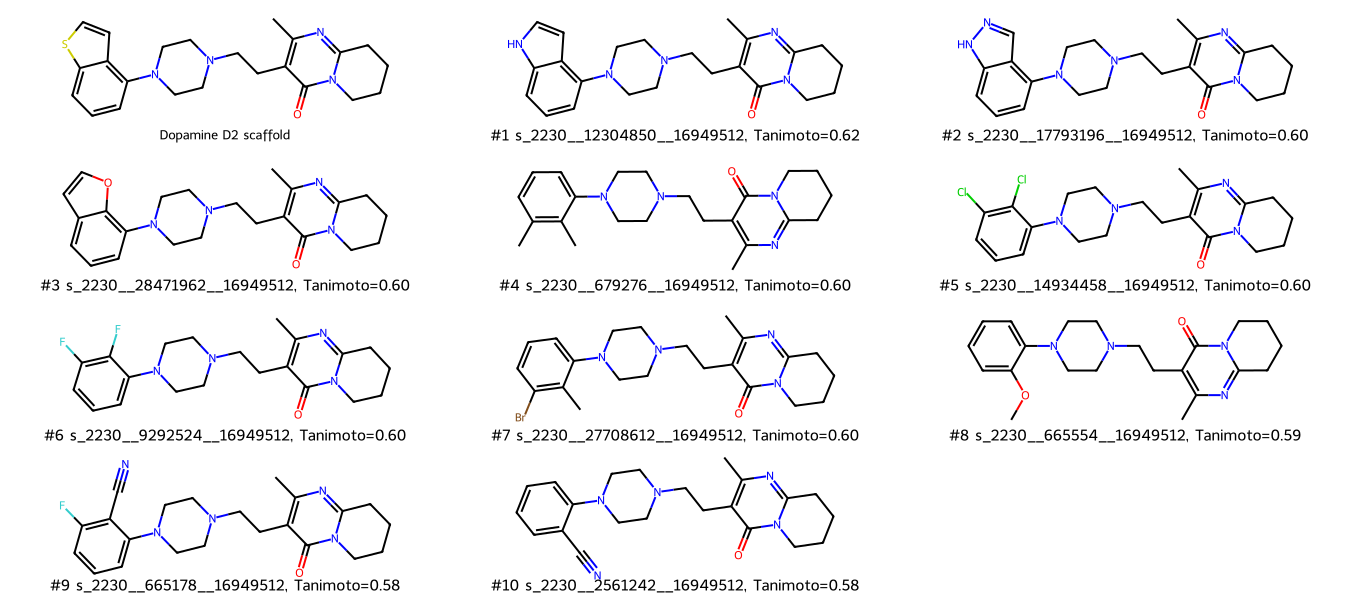

In [36]:
top_n_molecules = 10
top_molecules = molecule_dataset.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
top_molecules = top_molecules[:top_n_molecules]
legends = [
    f"#{index + 1} {molecule['hit_id']}, "
    f"Tanimoto={molecule['tanimoto_morgan']:.2f}"
    for index, molecule in top_molecules.iterrows()
]
top_molecules["ROMol"] = top_molecules["smiles"].apply(Chem.MolFromSmiles)
Chem.Draw.MolsToGridImage(
    mols=[query] + top_molecules["ROMol"].tolist(),
    legends=(["Dopamine D2 scaffold"] + legends),
    molsPerRow=3,
    subImgSize=(450, 150),
)

In [37]:
molecule_dataset.head(3)

,alignment,dist,ecfp4,daylight,maj,min,hyb,sub,smiles,hit_id,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,1,0.701493,0.733906,1,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__12304850__16949512,0.929825,0.625000,0.963636,0.769231
1,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=NC=NC5=C...,2,0.691176,0.697761,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=NC=NC5=C...,s_2230__24395838__16949512,0.982456,0.560000,0.991150,0.717949
2,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,2,0.676471,0.734783,2,0,0,0,CC1=C(C(=O)N2CCCCC2=N1)CCN3CCN(CC3)C4=CC=CC5=C...,s_2230__17793196__16949512,0.868852,0.598361,0.929825,0.748718


In [38]:
def get_enrichment_data(molecules, similarity_measure, pic50_cutoff):
    """
    Calculates x and y values for enrichment plot:
        x - % ranked dataset
        y - % true actives identified

    Parameters
    ----------
    molecules : pandas.DataFrame
        Molecules with similarity values to a query molecule.
    similarity_measure : str
        Column name which will be used to sort the DataFrame．
    pic50_cutoff : float
        pIC50 cutoff value used to discriminate active and inactive molecules.

    Returns
    -------
    pandas.DataFrame
        Enrichment data: Percentage of ranked dataset by similarity vs. percentage of identified true actives.
    """

    # Get number of molecules in data set
    molecules_all = len(molecules)

    # Get number of active molecules in data set
    actives_all = sum(molecules["pIC50"] >= pic50_cutoff)

    # Initialize a list that will hold the counter for actives and molecules while iterating through our dataset
    actives_counter_list = []

    # Initialize counter for actives
    actives_counter = 0

    # Note: Data must be ranked for enrichment plots:
    # Sort molecules by selected similarity measure
    molecules.sort_values([similarity_measure], ascending=False, inplace=True)

    # Iterate over the ranked dataset and check each molecule if active (by checking bioactivity)
    for value in molecules["pIC50"]:
        if value >= pic50_cutoff:
            actives_counter += 1
        actives_counter_list.append(actives_counter)

    # Transform number of molecules into % ranked dataset
    molecules_percentage_list = [i / molecules_all for i in range(1, molecules_all + 1)]

    # Transform number of actives into % true actives identified
    actives_percentage_list = [i / actives_all for i in actives_counter_list]

    # Generate DataFrame with x and y values as well as label
    enrichment = pd.DataFrame(
        {
            "% ranked dataset": molecules_percentage_list,
            "% true actives identified": actives_percentage_list,
        }
    )

    return enrichment

In [39]:
pic50_cutoff = 6.3

In [41]:
similarity_measures = ["tanimoto_maccs", "tanimoto_morgan"]
if "pIC50" not in molecule_dataset.columns:
    print(
        "Enrichment analysis skipped: molecule_dataset has no 'pIC50' column. "
        "Load or merge bioactivity data before calculating enrichment."
    )
    enrichment_data = {}
else:
    molecule_dataset["pIC50"] = pd.to_numeric(
        molecule_dataset["pIC50"], errors="coerce"
    )
    molecule_dataset = molecule_dataset.dropna(subset=["pIC50"])

    enrichment_data = {
        similarity_measure: get_enrichment_data(
            molecule_dataset.copy(),
            similarity_measure,
            pic50_cutoff,
        )
        for similarity_measure in similarity_measures
    }

Enrichment analysis skipped: molecule_dataset has no 'pIC50' column. Load or merge bioactivity data before calculating enrichment.


In [42]:
# NBVAL_CHECK_OUTPUT
enrichment_data["tanimoto_maccs"].head()

KeyError: 'tanimoto_maccs'

KeyError: 'pIC50'

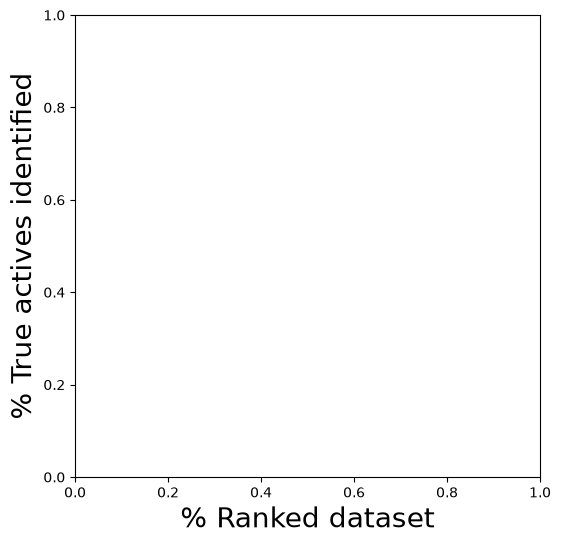

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))

fontsize = 20

# Plot enrichment data
for similarity_measure, enrichment in enrichment_data.items():
    ax = enrichment.plot(
        ax=ax,
        x="% ranked dataset",
        y="% true actives identified",
        label=similarity_measure,
        alpha=0.5,
        linewidth=4,
    )
ax.set_ylabel("% True actives identified", size=fontsize)
ax.set_xlabel("% Ranked dataset", size=fontsize)

# Plot optimal curve: Ratio of actives in dataset
ratio_actives = sum(molecule_dataset["pIC50"] >= pic50_cutoff) / len(molecule_dataset)
ax.plot(
    [0, ratio_actives, 1],
    [0, 1, 1],
    label="Optimal curve",
    color="black",
    linestyle="--",
)

# Plot random curve
ax.plot([0, 1], [0, 1], label="Random curve", color="grey", linestyle="--")

plt.tick_params(labelsize=16)
plt.legend(
    labels=["MACCS", "Morgan", "Optimal", "Random"],
    loc=(0.5, 0.08),
    fontsize=fontsize,
    labelspacing=0.3,
)

# Save plot -- use bbox_inches to include text boxes
plt.savefig(
    DATA / "enrichment_plot.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

plt.show()